### **Sentiment Analysis con VADER**

In questo notebook si effettuerà una **Sentiment Analysis** utilizzando **VADER (Valence Aware Dictionary and Sentiment Reasoner)**, strumento ottimizzato per i testi dei social media.

Al fine di catturare le sfumature semantiche e psicologiche delle richieste, è stata implementata una strategia di Feature Engineering, combinando **analisi del sentimento**, **dizionari lessicali specifici** per il dominio e **modellazione dei topic** latenti.

In [12]:
# Installazione delle dipendenze
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from scipy.sparse import hstack
import pickle
import scipy.sparse
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

nltk.download('vader_lexicon', quiet=True)

True

In [14]:
# Caricamento del Dataset (Pickle)
df = pd.read_pickle('data/train/00_train.pkl')
print(f"Dataset caricato: {df.shape[0]} righe")
print(f"Colonne: {list(df.columns)}")

Dataset caricato: 4040 righe
Colonne: ['text', 'tags', 'target', 'timestamp', 'account_age_days', 'num_comments', 'karma', 'num_subreddits', 'text_length', 'word_count', 'processed_text', 'processed_text_length', 'processed_text_word_count']


#### **Sentiment Analysis, Feature Engineering e Topic Modeling**

Le nuove variabili generate si divideranno in quattro macro-categorie:

**1. Sentiment Analysis**

Utilizzando **VADER** è stata valutata la polarità emotiva di ogni richiesta.
- **Motivazione**: si ipotizza che il tono emotivo (positivo, negativo o neutro) influenzi predisposizione della community a donare.
- **Variabili**: `vader_compound`, `vader_pos`, `vader_neg`.

**2. Feature Linguistiche Domain-Specific**

Sulla base della letteratura riguardante il dataset RAOP, sono stati creati dizionari personalizzati per contare la frequenza di termini appartenenti a categorie psicologiche rilevanti:

- **Struggle (Disagio)**: termini legati a difficoltà economiche o lavorative (_es: jobless, fired, broke_).
- **Politeness (Cortesia)**: termini di gratitudine (_es: please, thanks, appreciate_), spesso indicativi di successo.
- **Urgenza**: indicatori temporali (_es: tonight, asap_).
- **Concretezza (Money)**: riferimenti a spese specifiche (_es: bills, rent_), identificando anche i numeri mascherati (`_NUM_`) del preprocessing precedente.
- **Reciprocità**: rilevamento di promesse di "restituire il favore" (_pay it forward_).

**3. Topic Modeling**

Per individuare i temi latenti non catturati dalle singole parole chiave, è stata applicata la **Non Negative Matrix Factorization (NMF)** sulla matrice **TF-IDF**. Il corpus è stato decomposto in 5 topic principali. Ogni richiesta riceve uno score di appartenenza a ciascun topic (es. "Topic Studente", "Topic Famiglia", ecc.).

**4. Feature Temporali e Metadati**

Sono state derivate variabili temporali per testare ipotesi comportamentali:
- **Is Month End**: indica se la richiesta è stata fatta dopo il giorno 25 del mese (periodo in cui stipendi/fondi tendono a esaurirsi).
- **Is Weekend**: indica se la richiesta è stata fatta nel fine settimana.


Calcolo sentiment VADER...

Aggiunta features linguistiche...
Features aggiunte: kw_struggle, kw_family, kw_politeness, kw_urgency, kw_money_concrete...

Aggiunta features temporali...

Creazione features testuali e Topic Modeling...
  TF-IDF shape: (4040, 2000)
  Esecuzione NMF Topic Modeling...

STATISTICHE PER TARGET

vader_compound:
            mean       std   median
target                             
0       0.488793  0.564317  0.75375
1       0.542917  0.543163  0.81355

word_count:
              mean        std  median
target                               
0        83.999672  66.833575    67.0
1       102.542254  75.534435    83.0

karma:
               mean          std  median
target                                  
0       1090.904465  2956.582633   135.5
1       1372.060362  5419.691555   285.5


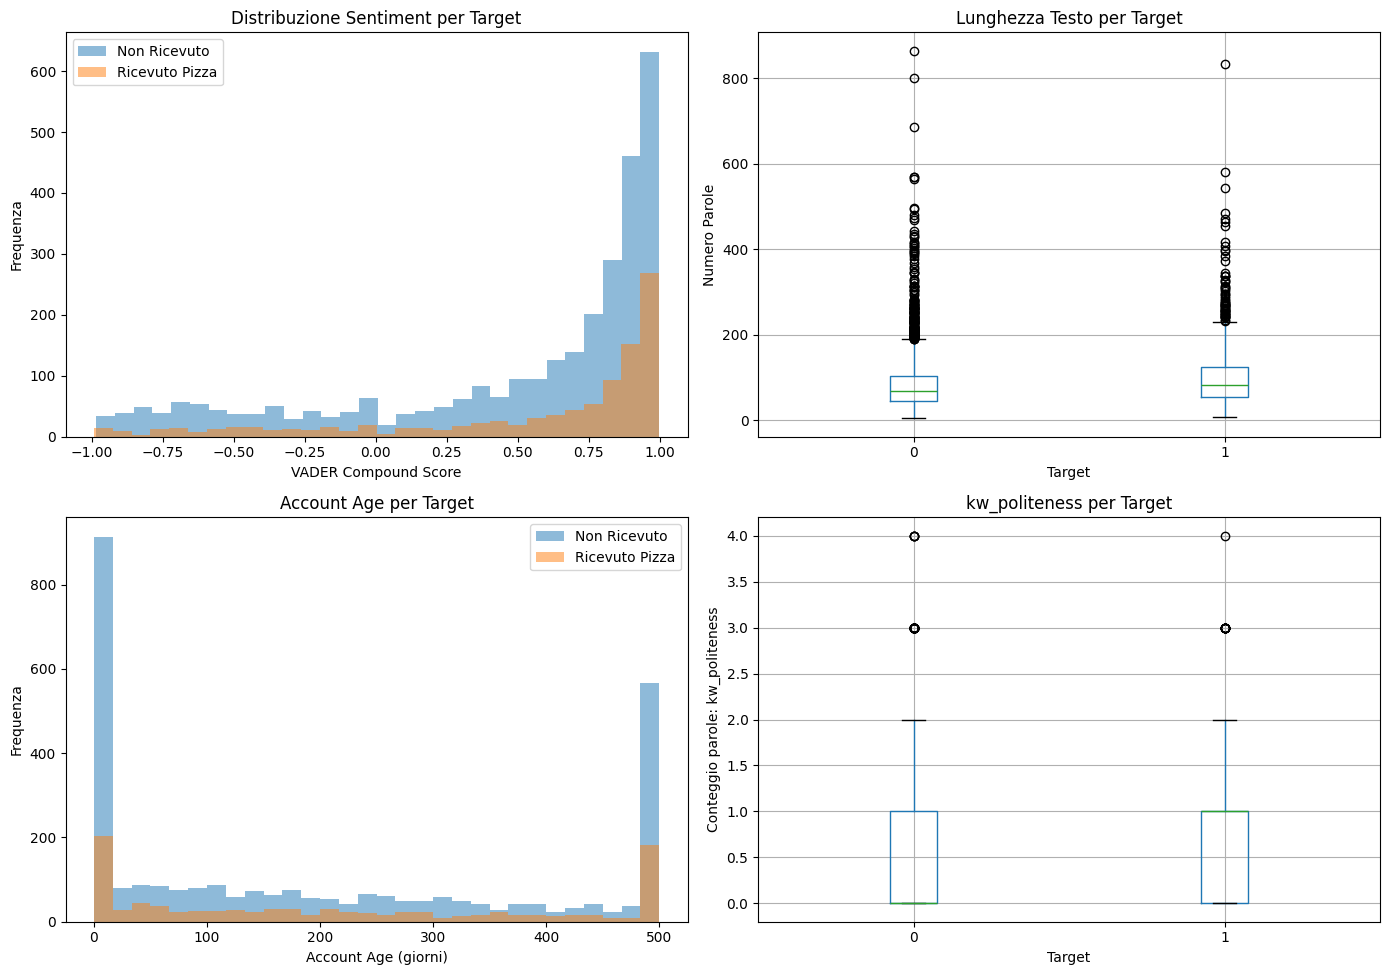

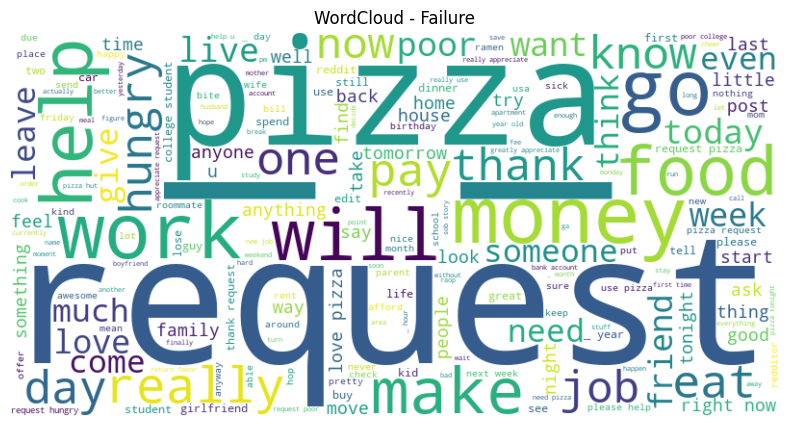

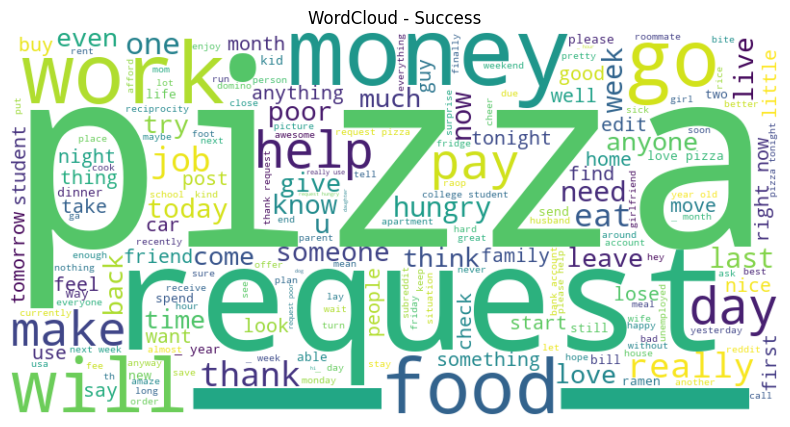

In [15]:
# Sentiment Analysis con VADER
def add_vader_sentiment(df):
    print("\nCalcolo sentiment VADER...")
    sia = SentimentIntensityAnalyzer()
    # VADER lavora meglio su testo grezzo (con maiuscole e punteggiatura)
    df['vader_compound'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    df['vader_pos'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['pos'])
    df['vader_neg'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['neg'])
    return df

# Aggiunta di Features Linguistiche
def add_linguistic_features(df):
    print("\nAggiunta features linguistiche...")

    # Categorie più specifiche basate sul nuovo preprocessing
    keywords_dict = {
        # Disperazione / Bisogno
        'struggle': ['struggling', 'jobless', 'unemployed', 'fired', 'broke', 'sick', 'hospital', 'homeless', 'starving'],
        # Famiglia / Altri
        'family': ['kids', 'children', 'son', 'daughter', 'family', 'mom', 'wife', 'baby'],
        # Gratitudine / Cortesia (Molto predittivo!)
        'politeness': ['please', 'thanks', 'thank', 'appreciate', 'grateful', 'kindness'],
        # Urgenza / Tempo (Il preprocessing ha mantenuto queste parole)
        'urgency': ['now', 'tonight', 'today', 'immediately', 'asap', 'soon', 'tomorrow'],
        # Soldi / Concretezza (Cerca il token _NUM_ inserito dal preprocessing)
        'money_concrete': ['_NUM_', 'rent', 'bill', 'bills', 'check', 'paycheck', 'paid', 'loan']
    }

    # Calcolo del conteggio per ogni categoria usando 'processed_text'
    for category, words in keywords_dict.items():
        df[f'kw_{category}'] = df['processed_text'].apply(
            lambda x: sum(1 for w in words if w in str(x).split())
        )

    # Reciprocità
    reciprocity_phrases = ['pay it forward', 'return the favor', 'pay you back', 'pay back', 'repay']
    df['offers_reciprocity'] = df['text'].apply(lambda x: int(any(p in str(x).lower() for p in reciprocity_phrases)))
    
    # Lunghezza e Punteggiatura (sul testo originale per catturare lo stile)
    df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
    df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
    df['text_len_char'] = df['text'].apply(len)
    
    print("Features aggiunte: kw_struggle, kw_family, kw_politeness, kw_urgency, kw_money_concrete...")
    return df

# Creazione Feature Temporali
def add_temporal_features(df):
    print("\nAggiunta features temporali...")
    # Conversione sicura timestamp
    if not np.issubdtype(df['timestamp'].dtype, np.datetime64):
        dt = pd.to_datetime(df['timestamp'], unit='s')
    else:
        dt = df['timestamp']
        
    df['hour'] = dt.dt.hour
    df['month'] = dt.dt.month
    df['day_of_week'] = dt.dt.dayofweek
    
    # Feature derivate
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    # Fine mese (spesso finiscono i soldi)
    df['is_month_end'] = dt.dt.day.apply(lambda x: 1 if x > 25 else 0)
    
    return df

# Creazione Features Testuali
def create_text_features(df, max_tfidf_features=2000, n_topics=5):
    print("\nCreazione features testuali e Topic Modeling...")
    
    # TF-IDF (Si aumentano le feature a 2000 per catturare più sfumature)
    tfidf_vectorizer = TfidfVectorizer(
        max_features=max_tfidf_features,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.90
    )
    tfidf_features = tfidf_vectorizer.fit_transform(df['processed_text'].fillna(''))
    print(f"  TF-IDF shape: {tfidf_features.shape}")
    
    # --- Topic Modeling (NMF) ---
    # Estrazione dei "temi" latenti (es. Studente, Disoccupato, Voglia di Pizza)
    print("  Esecuzione NMF Topic Modeling...")
    nmf = NMF(n_components=n_topics, random_state=42, init='nndsvda', max_iter=500)
    topic_matrix = nmf.fit_transform(tfidf_features)
    
    # Aggiunta dei topic al dataframe come colonne
    topic_cols = [f'topic_{i}' for i in range(n_topics)]
    topic_df = pd.DataFrame(topic_matrix, columns=topic_cols, index=df.index)
    df = pd.concat([df, topic_df], axis=1)
    
    # Vectorizzazione Tag (Subreddit)
    tag_vectorizer = CountVectorizer(max_features=50, binary=True)
    tag_features = tag_vectorizer.fit_transform(df['tags'].fillna(''))
    
    # Per il modello finale: tfidf sparso + tag sparsi
    # Le feature dense (topic, sentiment, linguistiche) vanno gestite a parte nel 'numeric_features'
    text_features_sparse = hstack([tfidf_features, tag_features])
    
    return text_features_sparse, tfidf_vectorizer, tag_vectorizer, topic_cols

# Creazione Features Numeriche
def get_numeric_features(df, topic_cols):
    numeric_cols = [
        # Engagement & User
        'account_age_days', 'num_comments', 'karma', 'num_subreddits', 
        # Text Structure
        'text_len_char', 'word_count', 'processed_text_length', 
        # Sentiment
        'vader_compound', 'vader_pos', 'vader_neg',
        # Linguistic & Content
        'kw_struggle', 'kw_family', 'kw_politeness', 'kw_urgency', 'kw_money_concrete',
        'offers_reciprocity', 'exclamation_count', 'question_count', 'has_emoji',
        # Temporal
        'hour', 'is_weekend', 'is_month_end'
    ] + topic_cols # Aggiunta dei topic dinamicamente
    
    # Verifica esistenza colonne
    available_cols = [col for col in numeric_cols if col in df.columns]
    return df[available_cols].fillna(0)

# Creazione Visualizzazioni
def create_visualizations(df):
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distribuzione sentiment per target
    ax1 = axes[0, 0]
    for target in [0, 1]:
        subset = df[df['target'] == target]['vader_compound']
        label = 'Ricevuto Pizza' if target == 1 else 'Non Ricevuto'
        ax1.hist(subset, bins=30, alpha=0.5, label=label)
    ax1.set_xlabel('VADER Compound Score')
    ax1.set_ylabel('Frequenza')
    ax1.set_title('Distribuzione Sentiment per Target')
    ax1.legend()
    
    # 2. Lunghezza testo per target
    ax2 = axes[0, 1]
    df.boxplot(column='word_count', by='target', ax=ax2)
    ax2.set_xlabel('Target')
    ax2.set_ylabel('Numero Parole')
    ax2.set_title('Lunghezza Testo per Target')
    plt.suptitle('')
    
    # 3. Account age per target
    ax3 = axes[1, 0]
    for target in [0, 1]:
        subset = df[df['target'] == target]['account_age_days']
        label = 'Ricevuto Pizza' if target == 1 else 'Non Ricevuto'
        ax3.hist(subset.clip(upper=500), bins=30, alpha=0.5, label=label)
    ax3.set_xlabel('Account Age (giorni)')
    ax3.set_ylabel('Frequenza')
    ax3.set_title('Account Age per Target')
    ax3.legend()
    
    # 4. Feature Politeness (Cortesia) per target
    ax4 = axes[1, 1]
    # Verifica che la colonna esista prima di plottare
    col_to_plot = 'kw_politeness' if 'kw_politeness' in df.columns else 'emotional_words_count'
    
    if col_to_plot in df.columns:
        df.boxplot(column=col_to_plot, by='target', ax=ax4)
        ax4.set_xlabel('Target')
        ax4.set_ylabel(f'Conteggio parole: {col_to_plot}')
        ax4.set_title(f'{col_to_plot} per Target')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    
    # WordCloud
    for target in [0, 1]:
        text = ' '.join(df[df['target'] == target]['processed_text'].fillna(''))
        if len(text) > 0:
            wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            label = 'success' if target == 1 else 'failure'
            plt.title(f'WordCloud - {label.title()}')
            plt.show()

# --- PIPELINE DI PREPROCESSING ---

# Aggiunta features
df = add_vader_sentiment(df)
df = add_linguistic_features(df)
df = add_temporal_features(df)

# Features testuali + Topic Modeling
text_features_sparse, tfidf_vec, tag_vec, topic_cols = create_text_features(df) 

# Features numeriche
numeric_features = get_numeric_features(df, topic_cols)

# Statistiche descrittive per target
print("\n" + "="*60)
print("STATISTICHE PER TARGET")
print("="*60)
    
for col in ['vader_compound', 'emotional_words_count', 'word_count', 'karma']:
    if col in df.columns:
        print(f"\n{col}:")
        print(df.groupby('target')[col].agg(['mean', 'std', 'median']))
  
# Visualizzazioni
create_visualizations(df)

#### **Analisi dei risultati**

L'esplorazione grafica delle nuove feature rivela **pattern distintivi** tra le richieste di successo e quelle fallite.

**Analisi delle Distribuzioni**

   - **1. Sentiment**: la distribuzione del compound score per le richieste di successo (arancione) è leggermente spostata verso valori più positivi rispetto ai fallimenti.

   - **2. Lunghezza del testo**: i boxplot evidenziano che **chi riceve la pizza tende a scrivere di più**. La media delle parole per i target positivi è 102.5 contro 84.0 dei negativi.

   - **3. Età Account**: gli utenti che ricevono pizza hanno, in media, account più vecchi e consolidati.

   - **4. Cortesia**: l'uso di parole gentili è mediamente superiore nelle richieste che vanno a buon fine.

**WordClouds a Confronto**

Le nuvole di parole permettono di visualizzare i termini più frequenti per le due classi.

   - **1. Fallimenti**: termini come "work", "job", "money", "pay" sono predominanti. Questo suggerisce che le richieste troppo focalizzate sulla mancanza di lavoro o puramente transazionali potrebbero essere meno efficaci.

   - **2. Successi**: sebbene "money" sia presente, emergono con forza termini come "tonight", "love". Sembra esserci una narrazione più focalizzata sul desiderio immediato del cibo e sull'aspetto emotivo/comunitario.

**Sintesti Statistica**

I dati confermano quantitativamente le osservazioni visive:
   - **Karma Utente**: chi riceve pizza ha un karma mediano più che doppio (285.5) rispetto a chi non la riceve (135.5). La reputazione su Reddit è un fattore chiave.
   - **Lunghezza**: scrivere una richiesta articolata (media >100 parole) aumenta le probabilità di successo.

In [16]:
# 1. Salvataggio DataFrame (Contiene Sentiment, Linguistics, Temporal, Topics)
df.to_pickle("data/train/01_train_enriched.pkl")

# 2. Salvataggio Matrice Sparsa (TF-IDF + Tags)
scipy.sparse.save_npz("data/train/01_text_features_sparse.npz", text_features_sparse)

# 3. Salvataggio Oggetti Fittati (Vectorizer e NMF)
with open('data/train/01_transformers.pkl', 'wb') as f:
    pickle.dump({
        'tfidf_vec': tfidf_vec,
        'tag_vec': tag_vec,
    }, f)

print("Pipeline salvata: DataFrame, Matrice Sparsa e Trasformatori salvati correttamente.")

Pipeline salvata: DataFrame, Matrice Sparsa e Trasformatori salvati correttamente.
